# Optuna Study Visualization: Budget DPO HPO

This notebook visualizes the Optuna study from `checkpoints/optuna/budget_dpo_hpo_0503_200745.db` to extract insights for improving future hyperparameter optimization runs.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
    plot_contour,
    plot_slice,
    plot_intermediate_values,
    plot_edf,
)
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Load the study
db_path = Path('/storage/arik/nlp_final_project/checkpoints/optuna/budget_dpo_hpo_0504_150740.db')

# Verify file exists
if not db_path.exists():
    raise FileNotFoundError(f"Database not found: {db_path}")

# Load with explicit study name
study = optuna.load_study(study_name=db_path.stem, storage=f'sqlite:///{db_path.as_posix()}')

print(f"Study name: {study.study_name}")
print(f"Number of trials: {len(study.trials)}")
print(f"Best value (neg val loss): {study.best_value:.6f}")
print(f"\nBest parameters:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Study name: budget_dpo_hpo_0504_150740
Number of trials: 17
Best value (neg val loss): -2.923012

Best parameters:
  lr: 1.0784138352776098e-06
  dpo_beta: 0.16431571593688898
  lambda_easy: 0.12350965819277088
  lambda_hard: 0.00020073416172452664
  gradient_accumulation_steps: 1
  length_ratio_easy: 2.872174371944398
  length_ratio_hard: 2.958612094674392
  max_pairs_per_problem: 20


## 1. Trial Summary Statistics

In [3]:
from optuna.trial import TrialState

# Count trial states
states = [t.state for t in study.trials]
state_counts = {state: states.count(state) for state in set(states)}

print("Trial States:")
for state, count in state_counts.items():
    print(f"  {state.name}: {count}")

# Get completed trials
completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
pruned_trials = [t for t in study.trials if t.state == TrialState.PRUNED]

print(f"\nCompleted trials: {len(completed_trials)}")
print(f"Pruned trials: {len(pruned_trials)}")

# Summary statistics for completed trials
if completed_trials:
    values = [t.value for t in completed_trials if t.value is not None]
    print(f"\nCompleted trial values (neg val loss):")
    print(f"  Best: {min(values):.6f}")
    print(f"  Worst: {max(values):.6f}")
    print(f"  Mean: {np.mean(values):.6f}")
    print(f"  Std: {np.std(values):.6f}")

Trial States:
  RUNNING: 1
  COMPLETE: 16

Completed trials: 16
Pruned trials: 0

Completed trial values (neg val loss):
  Best: -2.923012
  Worst: -0.579339
  Mean: -1.537470
  Std: 0.649518


## 2. Optimization History

Shows how the optimization progressed over trials. The best value found so far is shown in orange.

In [4]:
fig = plot_optimization_history(study)
fig.update_layout(title="Optimization History - Budget DPO HPO", height=500)
fig.show()

## 3. Parameter Importances

Shows which hyperparameters have the most impact on the objective value. Use this to focus future searches on the most influential parameters.

In [5]:
# Compute parameter importances using fANOVA
try:
    importances = optuna.importance.get_param_importances(study, evaluator=optuna.importance.FanovaImportanceEvaluator())
    print("Parameter Importances (fANOVA):")
    for param, importance in importances.items():
        print(f"  {param}: {importance:.4f}")

    fig = plot_param_importances(study, evaluator=optuna.importance.FanovaImportanceEvaluator())
    fig.update_layout(title="Hyperparameter Importances (fANOVA)", height=600)
    fig.show()
except Exception as e:
    print(f"Could not compute fANOVA importances: {e}")
    print("Trying default importance...")
    fig = plot_param_importances(study)
    fig.update_layout(title="Hyperparameter Importances", height=600)
    fig.show()

Parameter Importances (fANOVA):
  length_ratio_hard: 0.2821
  length_ratio_easy: 0.1929
  dpo_beta: 0.1631
  lambda_easy: 0.1239
  lambda_hard: 0.0894
  lr: 0.0656
  max_pairs_per_problem: 0.0476
  gradient_accumulation_steps: 0.0353


## 4. Parallel Coordinate Plot

Shows relationships between all parameters and the objective value. Look for parameter regions where the objective is best (darker blue lines).

In [6]:
fig = plot_parallel_coordinate(study)
fig.update_layout(title="Parallel Coordinate Plot - All Parameters", height=600)
fig.show()

## 5. Slice Plots (Parameter vs Objective)

Shows how each parameter individually affects the objective. Look for parameter ranges that consistently give better results.

In [7]:
fig = plot_slice(study, params=['length_ratio_easy', 'dpo_beta', 'length_ratio_hard', 'lambda_easy', 'lambda_hard'])
fig.update_layout(title="Parameter Slice Plots")
fig.show()

## 6. Contour Plots - Most Important Parameters

Shows interactions between the most important parameter pairs. Darker regions are better.

In [7]:
# Get top parameters by importance
try:
    importances = optuna.importance.get_param_importances(study)
    top_params = list(importances.keys())[:5]  # Top 5 most important

    print(f"Top 5 most important parameters: {top_params}")

    # Create contour plots for top parameter pairs
    for i in range(len(top_params)):
        for j in range(i+1, len(top_params)):
            param_x = top_params[i]
            param_y = top_params[j]
            try:
                fig = plot_contour(study, params=[param_x, param_y])
                fig.update_layout(title=f"Contour: {param_x} vs {param_y}", height=500)
                fig.show()
            except Exception as e:
                print(f"Could not plot contour for {param_x} vs {param_y}: {e}")
except Exception as e:
    print(f"Could not generate contour plots: {e}")

Top 5 most important parameters: ['dpo_beta', 'length_ratio_hard', 'length_ratio_easy', 'lr', 'lambda_easy']


## 7. Intermediate Values (for Pruned Trials)

Shows how trials progressed before being pruned. Helps understand if the pruning is working effectively.

In [8]:
fig = plot_intermediate_values(study)
fig.update_layout(title="Intermediate Values (Pruning Analysis)", height=500)
fig.show()

[W 2026-05-06 09:07:26,433] You need to set up the pruning feature to utilize `plot_intermediate_values()`


## 8. Empirical Distribution Function (EDF)

Shows the cumulative distribution of objective values. Steeper curve at higher values indicates more efficient optimization.

In [9]:
fig = plot_edf(study)
fig.update_layout(title="Empirical Distribution Function", height=500)
fig.show()

## 9. Detailed Trial Data Analysis

In [10]:
# Create DataFrame with all trial data
trials_data = []
for trial in study.trials:
    if trial.state == TrialState.COMPLETE and trial.value is not None:
        data = {'trial_number': trial.number, 'value': trial.value, 'state': trial.state.name}
        data.update(trial.params)
        trials_data.append(data)

df = pd.DataFrame(trials_data)
print(f"DataFrame shape: {df.shape}")
print(f"\nTop 5 trials by objective value (higher is better, since neg val loss):")
df_sorted = df.sort_values('value', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df_sorted.head(10).to_string(index=False))

DataFrame shape: (15, 11)

Top 5 trials by objective value (higher is better, since neg val loss):
 trial_number     value    state           lr  dpo_beta  lambda_easy  lambda_hard  gradient_accumulation_steps  length_ratio_easy  length_ratio_hard  max_pairs_per_problem
            8 -0.888907 COMPLETE 4.035708e-07  0.202591     0.242426     0.000323                            1           2.037699           2.115869                     19
            2 -0.962396 COMPLETE 8.016349e-07  0.111482     0.215223     0.000125                            2           2.184105           2.785176                     12
            7 -0.970716 COMPLETE 7.102641e-07  0.110182     0.197362     0.000125                            1           2.980330           2.772245                     12
            1 -1.023698 COMPLETE 1.250206e-06  0.081899     0.337052     0.000382                            1           1.775107           2.304242                     15
            4 -1.104294 COMPLETE 6.530943

In [11]:
# Parameter correlation with objective
print("\nCorrelation between parameters and objective (neg val loss):")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'value' in numeric_cols:
    correlations = df[numeric_cols].corr()['value'].sort_values(ascending=False)
    print(correlations[1:].to_string())  # Exclude self-correlation


Correlation between parameters and objective (neg val loss):
lambda_easy                    0.556478
gradient_accumulation_steps    0.375441
lambda_hard                   -0.269102
lr                            -0.339669
max_pairs_per_problem         -0.353220
length_ratio_easy             -0.459160
trial_number                  -0.459743
dpo_beta                      -0.492367
length_ratio_hard             -0.495931


## 10. Parameter Distributions for Top vs All Trials

Compare parameter distributions between top-performing trials and all trials.

Top 25% threshold (neg val loss): -1.063996
Top trials: 4, Other trials: 11


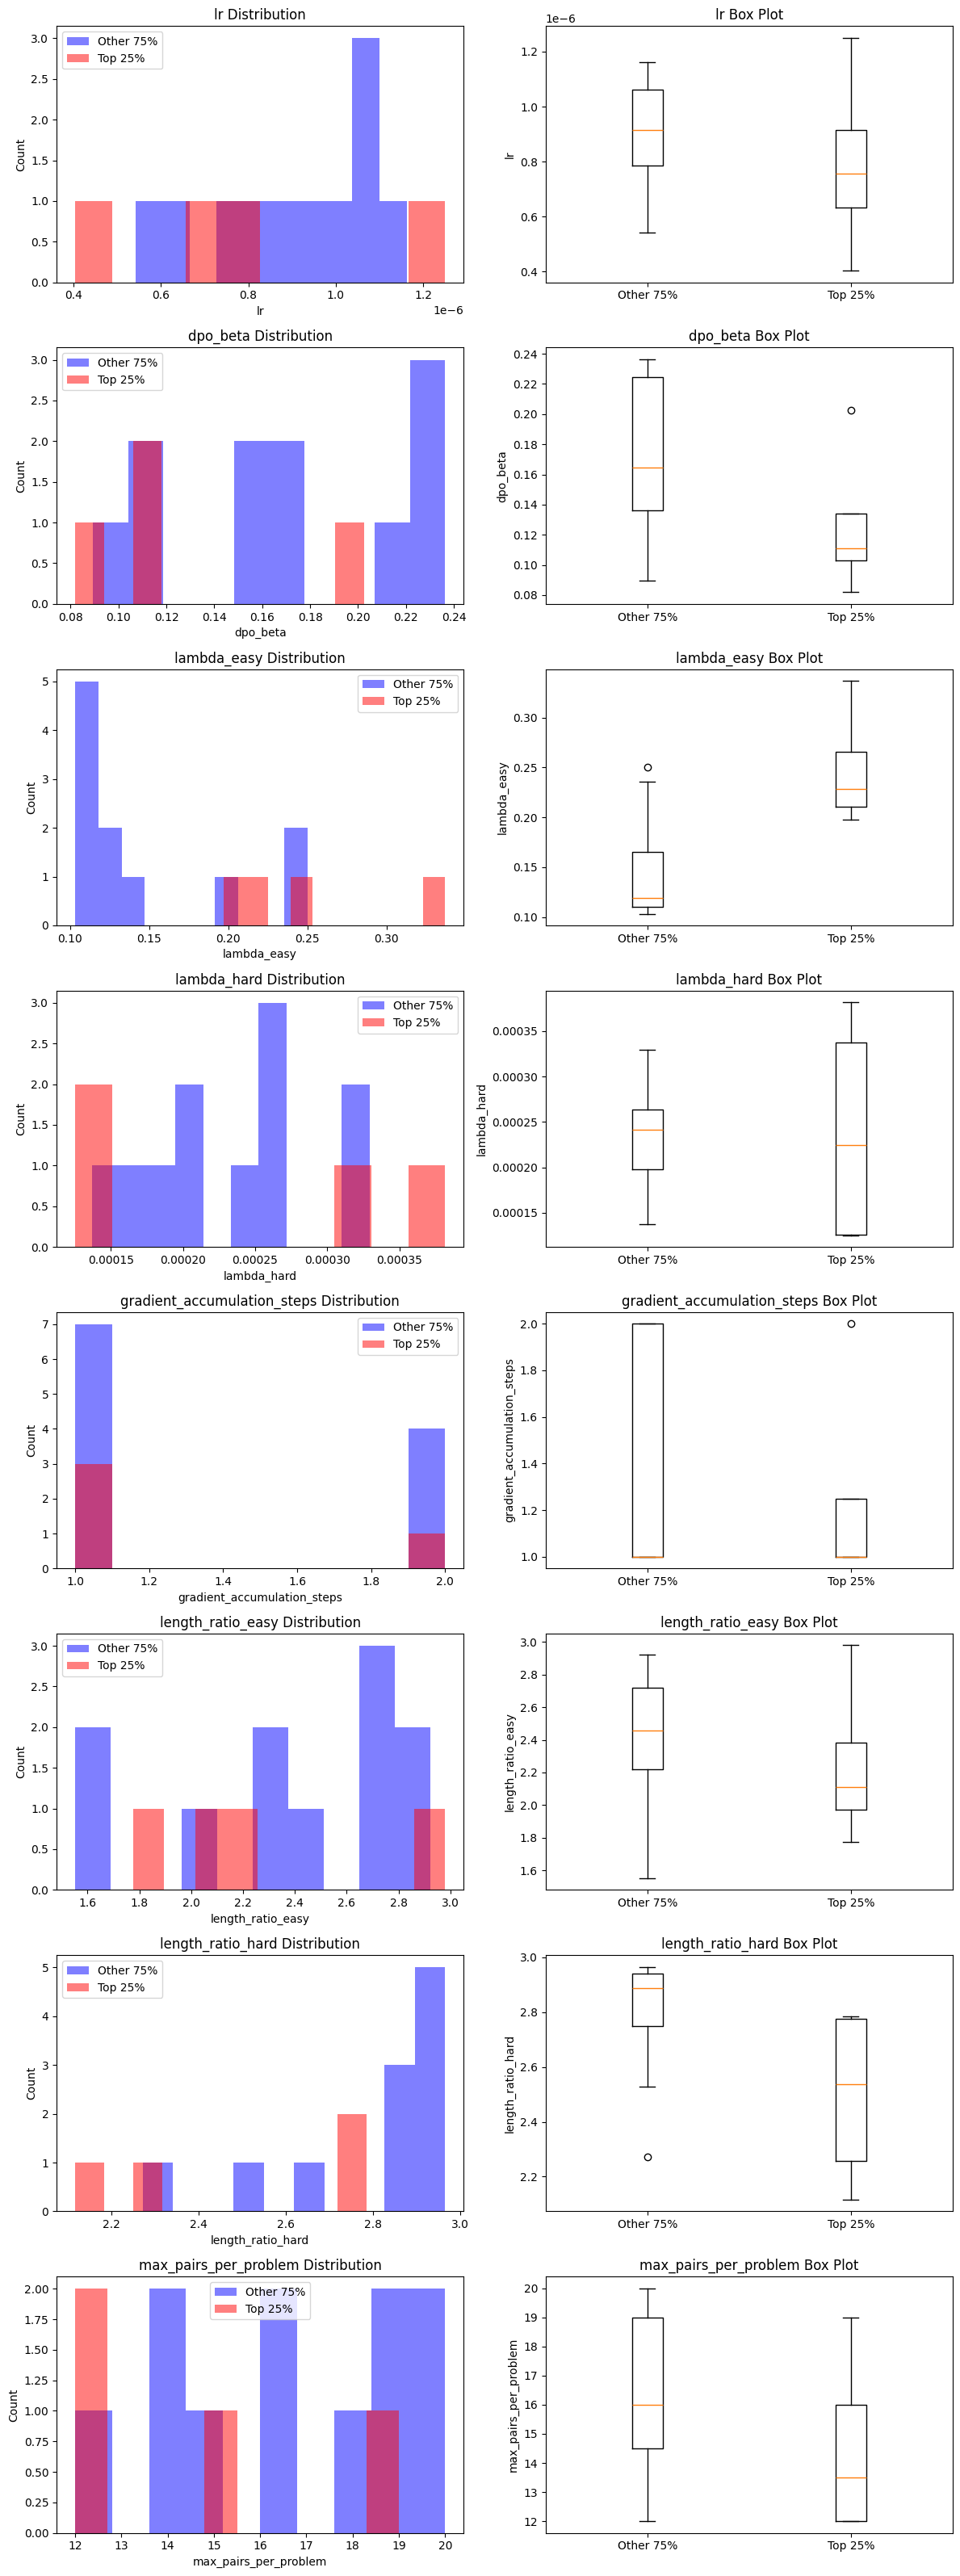

In [12]:
# Compare top 25% trials vs rest
if len(df) >= 4:
    threshold = df['value'].quantile(0.75)
    top_trials = df[df['value'] >= threshold]
    other_trials = df[df['value'] < threshold]

    print(f"Top 25% threshold (neg val loss): {threshold:.6f}")
    print(f"Top trials: {len(top_trials)}, Other trials: {len(other_trials)}")

    # Plot parameter distributions
    param_cols = [col for col in df.columns if col not in ['trial_number', 'value', 'state']]
    n_params = len(param_cols)

    fig, axes = plt.subplots(n_params, 2, figsize=(12, 4*n_params))
    if n_params == 1:
        axes = axes.reshape(1, -1)

    for idx, param in enumerate(param_cols):
        # Histogram comparison
        if df[param].dtype in [np.float64, np.int64]:
            axes[idx, 0].hist(other_trials[param], alpha=0.5, label='Other 75%', bins=10, color='blue')
            axes[idx, 0].hist(top_trials[param], alpha=0.5, label='Top 25%', bins=10, color='red')
            axes[idx, 0].set_xlabel(param)
            axes[idx, 0].set_ylabel('Count')
            axes[idx, 0].legend()
            axes[idx, 0].set_title(f'{param} Distribution')

            # Box plot comparison
            axes[idx, 1].boxplot([other_trials[param].dropna(), top_trials[param].dropna()], tick_labels=['Other 75%', 'Top 25%'])
            axes[idx, 1].set_title(f'{param} Box Plot')
            axes[idx, 1].set_ylabel(param)
        else:
            # Categorical parameter
            top_counts = top_trials[param].value_counts()
            other_counts = other_trials[param].value_counts()
            axes[idx, 0].bar(top_counts.index, top_counts.values, alpha=0.5, label='Top 25%', color='red')
            axes[idx, 0].bar(other_counts.index, other_counts.values, alpha=0.5, label='Other 75%', color='blue')
            axes[idx, 0].set_xlabel(param)
            axes[idx, 0].set_ylabel('Count')
            axes[idx, 0].legend()
            axes[idx, 0].set_title(f'{param} Distribution')
            axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough trials for top/bottom comparison")

## 11. Key Insights and Recommendations

Based on the analysis above, here are the key insights for improving future HPO runs:

In [13]:
print("="*80)
print("KEY INSIGHTS AND RECOMMENDATIONS FOR NEXT HPO RUN")
print("="*80)

# 1. Best parameters found
print("\n1. BEST PARAMETERS FOUND:")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

# 2. Parameter importance insights
try:
    importances = optuna.importance.get_param_importances(study)
    print("\n2. PARAMETER IMPORTANCE RANKING:")
    for i, (param, imp) in enumerate(importances.items(), 1):
        print(f"   {i}. {param}: {imp:.4f}")

    print("\n   RECOMMENDATION: Focus search on the top 3-4 parameters.")
    print(f"   The top parameter ({list(importances.keys())[0]}) explains "
          f"{list(importances.values())[0]*100:.1f}% of variance.")
except:
    pass

# 3. Trial efficiency
print(f"\n3. TRIAL EFFICIENCY:")
print(f"   - Completed trials: {len(completed_trials)}/{len(study.trials)} ({len(completed_trials)/len(study.trials)*100:.1f}%)")
print(f"   - Pruned trials: {len(pruned_trials)}/{len(study.trials)} ({len(pruned_trials)/len(study.trials)*100:.1f}%)")
if len(pruned_trials) / len(study.trials) > 0.5:
    print("   RECOMMENDATION: High pruning rate is good - consider increasing n_trials.")

# 4. Parameter range analysis
print("\n4. PARAMETER RANGE ANALYSIS:")
for param in study.best_params.keys():
    values = [t.params[param] for t in completed_trials if param in t.params]
    if values and all(isinstance(v, (int, float)) for v in values):
        best_val = study.best_params[param]
        min_val, max_val = min(values), max(values)
        position = (best_val - min_val) / (max_val - min_val) if max_val > min_val else 0.5
        print(f"   {param}: best at {position*100:.0f}th percentile of search range")
        if position < 0.1 or position > 0.9:
            print(f"      WARNING: Best value near boundary - consider extending search range!")

# 5. Specific recommendations
print("\n5. SPECIFIC RECOMMENDATIONS FOR NEXT RUN:")
print("   a) Increase n_trials to 50-100 for better exploration")
print("   b) Consider narrowing search ranges for parameters with low importance")
print("   c) For parameters where best is near boundary, extend that boundary")
print("   d) Use the best parameters as starting point with tighter search around them")
print("   e) Consider using TPESampler with multivariate=True for better sampling")

print("\n" + "="*80)

KEY INSIGHTS AND RECOMMENDATIONS FOR NEXT HPO RUN

1. BEST PARAMETERS FOUND:
   lr: 1.0784138352776098e-06
   dpo_beta: 0.16431571593688898
   lambda_easy: 0.12350965819277088
   lambda_hard: 0.00020073416172452664
   gradient_accumulation_steps: 1
   length_ratio_easy: 2.872174371944398
   length_ratio_hard: 2.958612094674392
   max_pairs_per_problem: 20

2. PARAMETER IMPORTANCE RANKING:
   1. dpo_beta: 0.3014
   2. length_ratio_hard: 0.2295
   3. lambda_easy: 0.1569
   4. lambda_hard: 0.0972
   5. lr: 0.0956
   6. length_ratio_easy: 0.0688
   7. gradient_accumulation_steps: 0.0303
   8. max_pairs_per_problem: 0.0202

   RECOMMENDATION: Focus search on the top 3-4 parameters.
   The top parameter (dpo_beta) explains 30.1% of variance.

3. TRIAL EFFICIENCY:
   - Completed trials: 15/16 (93.8%)
   - Pruned trials: 0/16 (0.0%)

4. PARAMETER RANGE ANALYSIS:
   lr: best at 80th percentile of search range
   dpo_beta: best at 53th percentile of search range
   lambda_easy: best at 9th perce

## 12. Generate Optimized Search Space for Next Run

Based on the analysis, here's a suggested search space for the next HPO run.

In [14]:
print("Suggested search space for next run (based on current best):")
print("\n" + "-"*80)
print("def suggest_parameters(trial):")
print("    # Learning rate - best was very low")
best_lr = study.best_params.get('lr', 1e-6)
print(f"    lr = trial.suggest_float('lr', {best_lr/2:.2e}, {best_lr*4:.2e}, log=True)")

# dpo_beta
best_beta = study.best_params.get('dpo_beta', 0.2)
print(f"    dpo_beta = trial.suggest_float('dpo_beta', {max(0.05, best_beta/2):.3f}, {min(0.5, best_beta*2):.3f})")

# lambda_easy
best_lambda_easy = study.best_params.get('lambda_easy', 0.3)
print(f"    lambda_easy = trial.suggest_float('lambda_easy', {max(0.01, best_lambda_easy/3):.3f}, {min(0.5, best_lambda_easy*2):.3f})")

# lambda_hard
best_lambda_hard = study.best_params.get('lambda_hard', 0.0001)
print(f"    lambda_hard = trial.suggest_float('lambda_hard', {best_lambda_hard/10:.6f}, {max(0.1, best_lambda_hard*10):.4f}, log=True)")

# kl_penalty
best_kl = study.best_params.get('kl_penalty_weight', 0.0001)
print(f"    kl_penalty_weight = trial.suggest_float('kl_penalty_weight', {best_kl/10:.6f}, {max(0.1, best_kl*10):.4f}, log=True)")

# length ratios
best_len_easy = study.best_params.get('length_ratio_easy', 2.0)
best_len_hard = study.best_params.get('length_ratio_hard', 3.0)
print(f"    length_ratio_easy = trial.suggest_float('length_ratio_easy', {max(1.0, best_len_easy/1.5):.2f}, {min(4.0, best_len_easy*1.5):.2f})")
print(f"    length_ratio_hard = trial.suggest_float('length_ratio_hard', {max(1.0, best_len_hard/1.5):.2f}, {min(5.0, best_len_hard*1.5):.2f})")

# max_pairs
best_max_pairs = study.best_params.get('max_pairs_per_problem', 13)
print(f"    max_pairs_per_problem = trial.suggest_int('max_pairs_per_problem', {max(5, best_max_pairs-5)}, {min(30, best_max_pairs+10)})")

print("\n    # Consider adding:")
print("    # loss_type = trial.suggest_categorical('loss_type', ['dpo', 'ipo', 'simpo'])")
print("    # batch_size = trial.suggest_categorical('batch_size', [4, 8, 16])")
print("    # gradient_accumulation_steps = trial.suggest_categorical('gradient_accumulation_steps', [1, 2, 4, 8])")
print("-"*80)

Suggested search space for next run (based on current best):

--------------------------------------------------------------------------------
def suggest_parameters(trial):
    # Learning rate - best was very low
    lr = trial.suggest_float('lr', 5.39e-07, 4.31e-06, log=True)
    dpo_beta = trial.suggest_float('dpo_beta', 0.082, 0.329)
    lambda_easy = trial.suggest_float('lambda_easy', 0.041, 0.247)
    lambda_hard = trial.suggest_float('lambda_hard', 0.000020, 0.1000, log=True)
    kl_penalty_weight = trial.suggest_float('kl_penalty_weight', 0.000010, 0.1000, log=True)
    length_ratio_easy = trial.suggest_float('length_ratio_easy', 1.91, 4.00)
    length_ratio_hard = trial.suggest_float('length_ratio_hard', 1.97, 4.44)
    max_pairs_per_problem = trial.suggest_int('max_pairs_per_problem', 15, 30)

    # Consider adding:
    # loss_type = trial.suggest_categorical('loss_type', ['dpo', 'ipo', 'simpo'])
    # batch_size = trial.suggest_categorical('batch_size', [4, 8, 16])
    # gra